
#  Práctica Calificada – Data Mining Tools

**Curso:** Data Mining Tools  
**Semestre:** 2025-2  
**Docente:** Ph. D. Carlos Fernando Montoya Cubas  
**Universidad Peruana de Ciencias Aplicadas**  

Dataset: [Stroke Prediction Dataset](https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset)  



## Instrucciones
- La práctica se realizará en **grupos**.  
- Cada pregunta vale **4 puntos** (1.5 puntos por codificación + 2.5 puntos por interpretación y documentación).  
- Entregar este notebook con las respuestas completadas.  
- Se permite usar como **clasificador auxiliar** cualquier modelo de sklearn (ej. Logistic Regression, RandomForest), únicamente para comparar el impacto de las transformaciones en las preguntas 4 y 5.  

### Restricción sobre LLMs
- Se permite el uso de **LLMs únicamente como apoyo en la codificación**.  
- **Está prohibido su uso en la interpretación**: las respuestas de análisis, justificación e interpretación deben ser propias.  
- Interpretaciones con formato evidente de autogeneración **no serán consideradas válidas**.  


In [11]:
import kagglehub
import pandas as pd
import sweetviz as sv
import seaborn as sns
import matplotlib.pyplot as plt
from ydata_profiling import ProfileReport


In [2]:
path = kagglehub.dataset_download("fedesoriano/stroke-prediction-dataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Administrador\.cache\kagglehub\datasets\fedesoriano\stroke-prediction-dataset\versions\1


In [3]:
data = pd.read_csv(path+"/healthcare-dataset-stroke-data.csv")


##  Pregunta 1 – EDA con librerías de visualización automática
- Realizar el **EDA utilizando SweetViz** y compararlo con otra librería de perfilado automático de datos (ejemplo: pandas-profiling, D-Tale, AutoViz, etc.).  
- Explicar ventajas/desventajas entre ambas herramientas.  


In [4]:
# Código aquí
eda_report_sv = sv.analyze(data)
eda_report_pp = ProfileReport(data, explorative=True)

                                             |          | [  0%]   00:00 -> (? left)


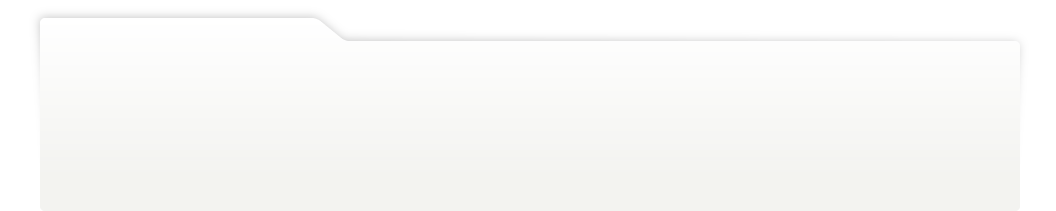
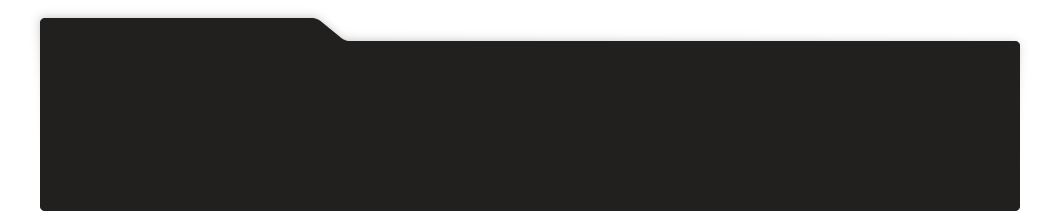
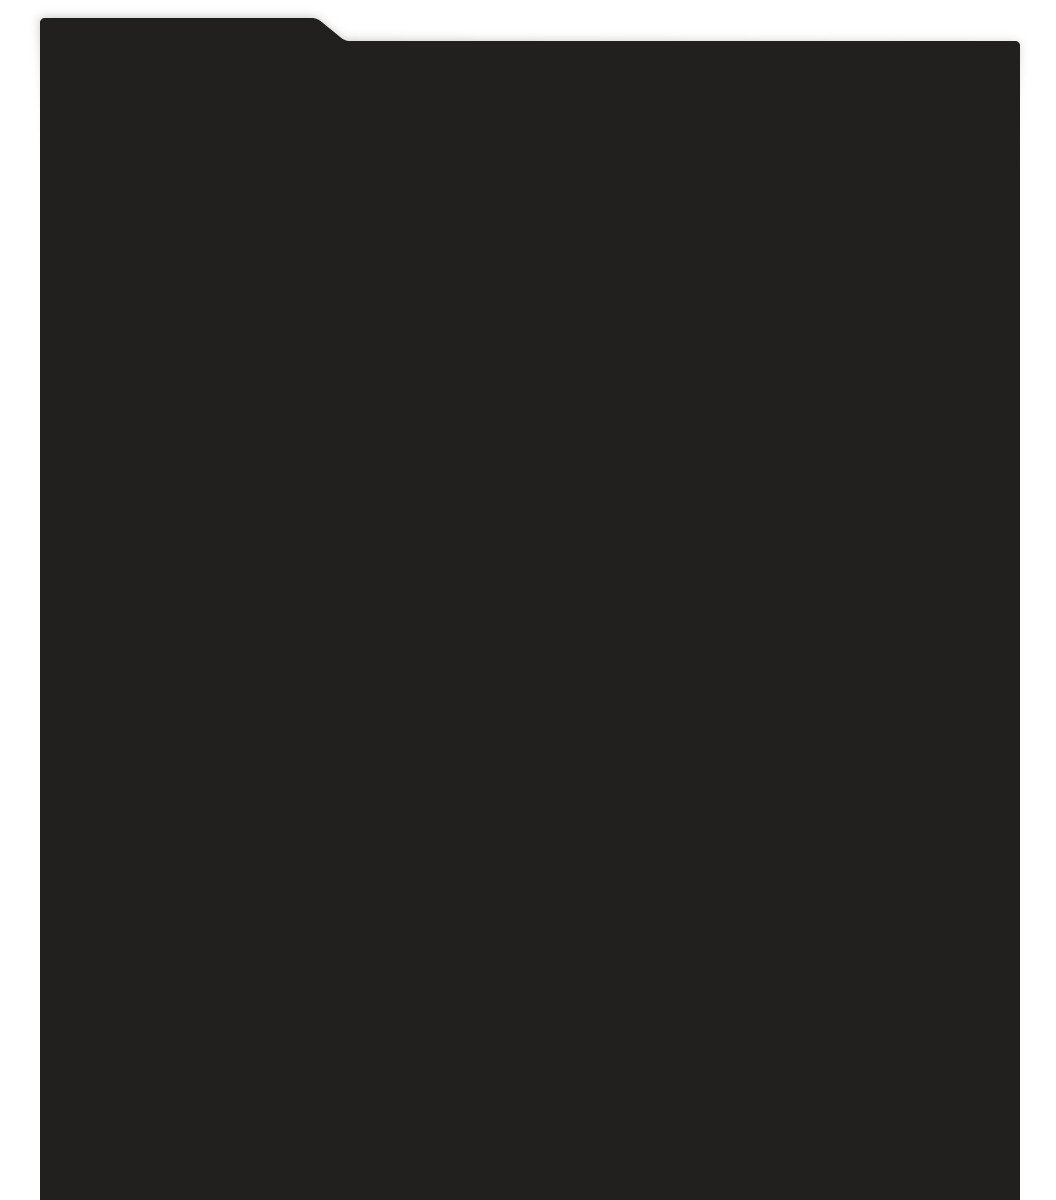
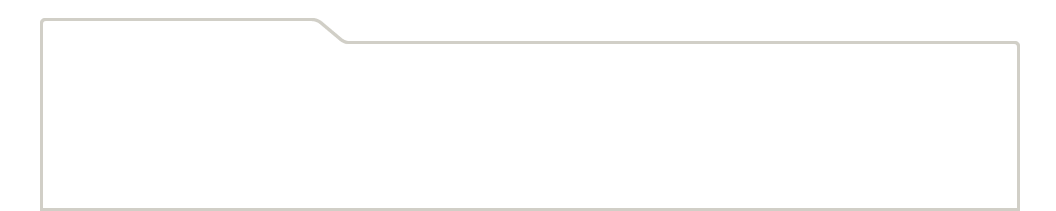
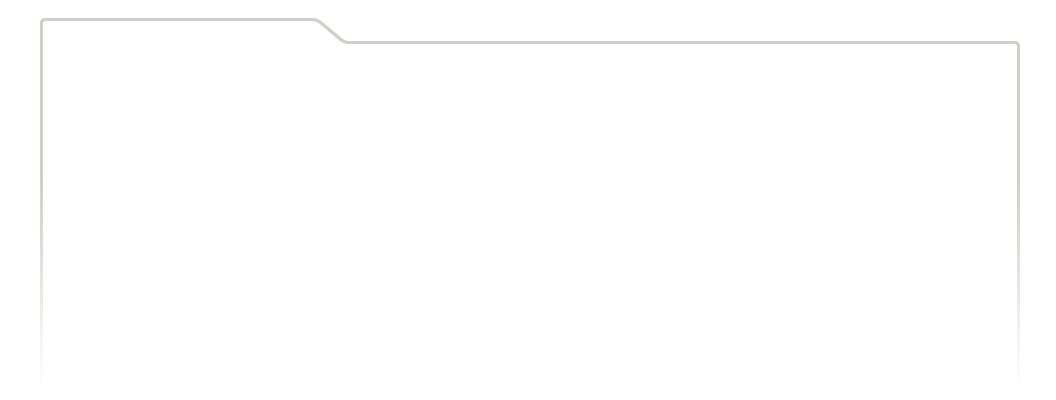
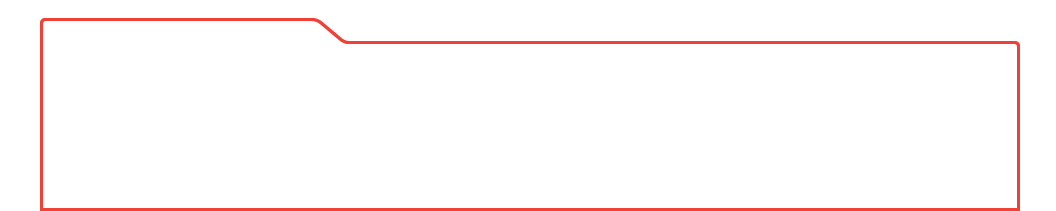
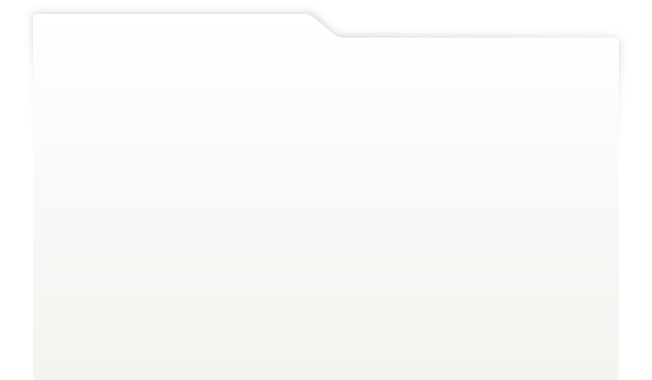
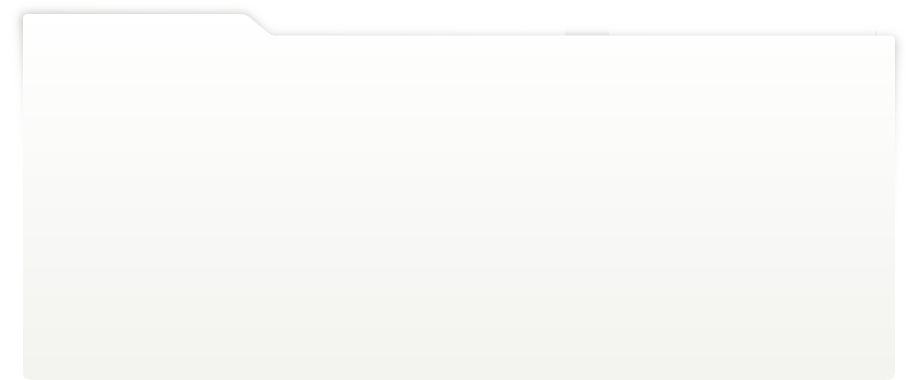
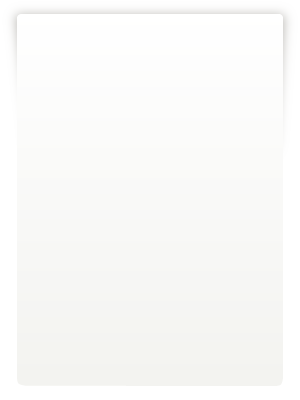
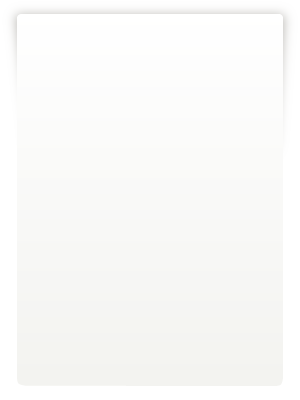
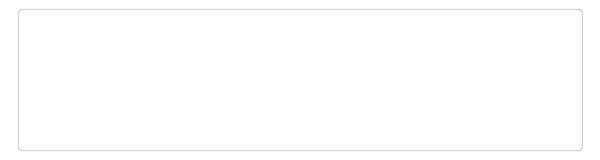
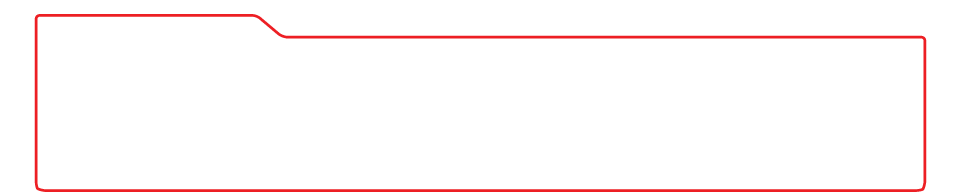
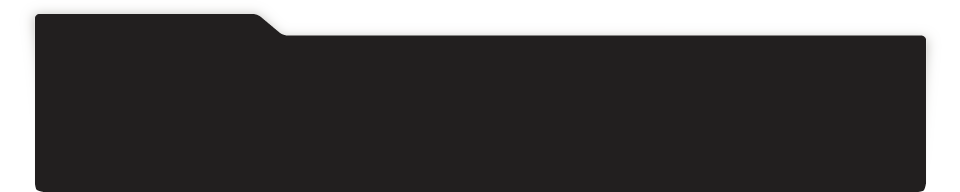
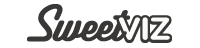
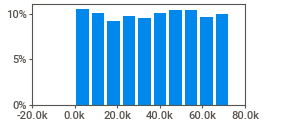
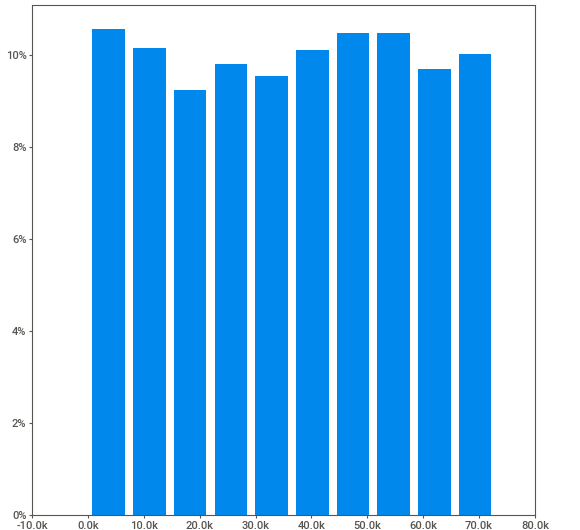
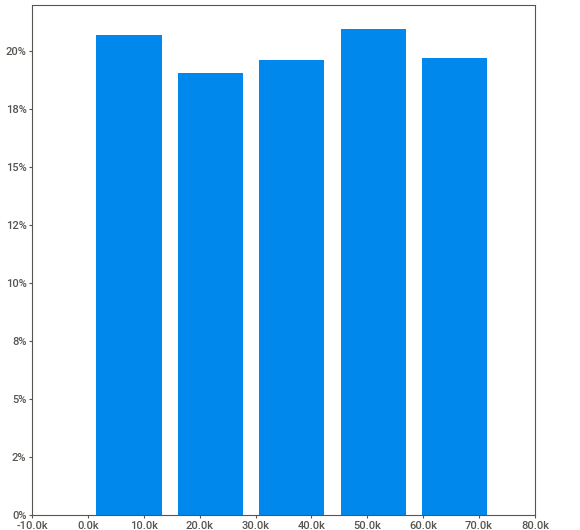
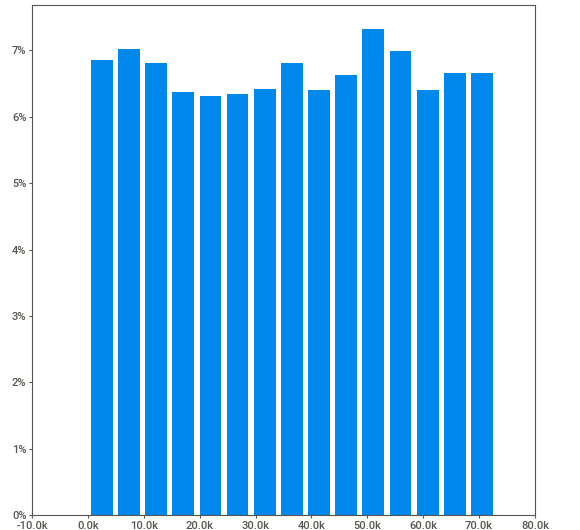
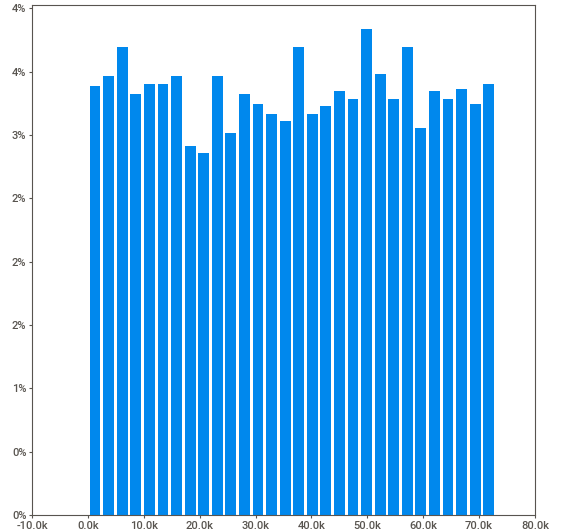
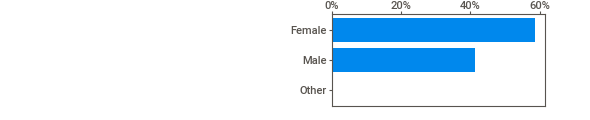
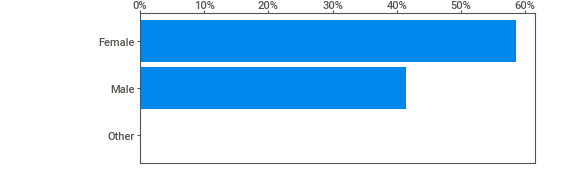
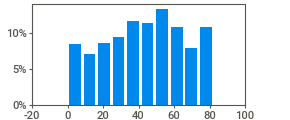
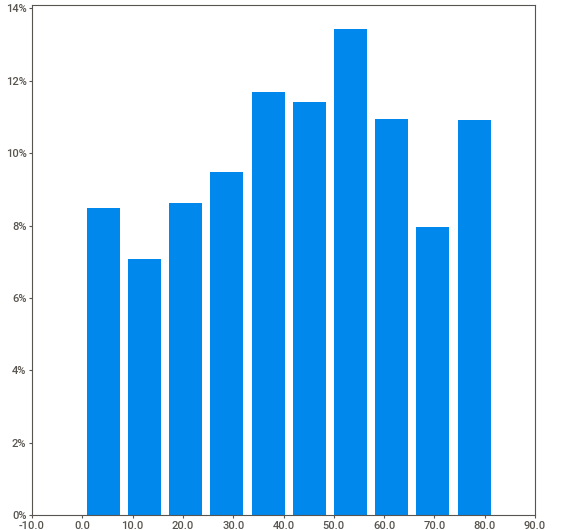
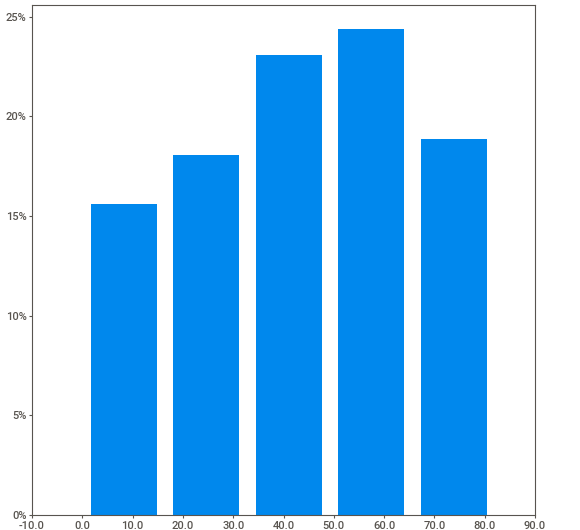
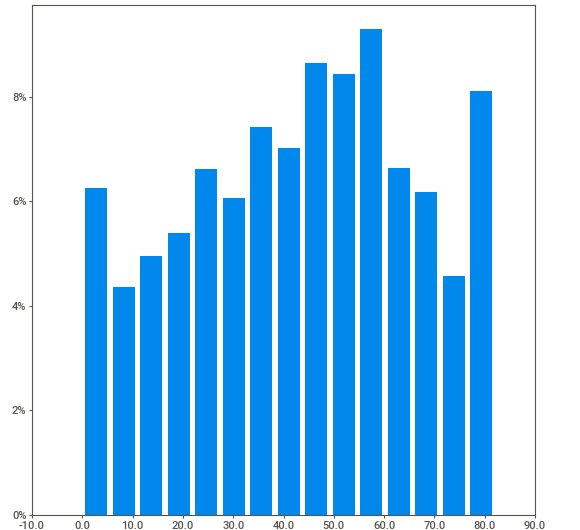
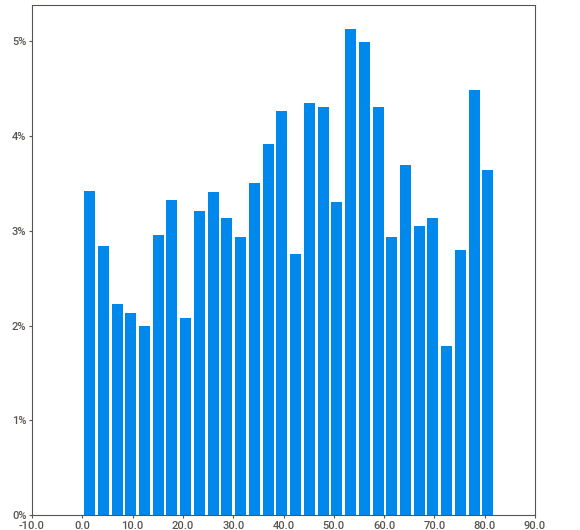
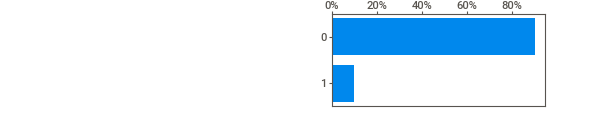
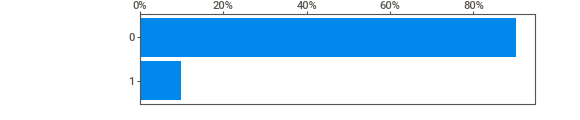
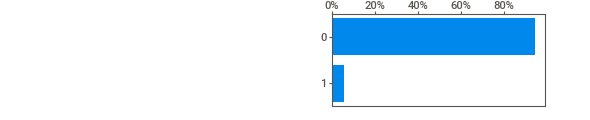
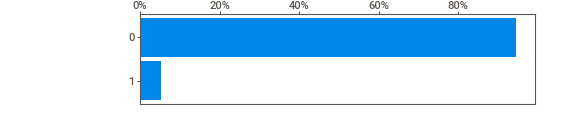
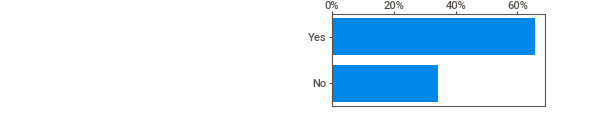
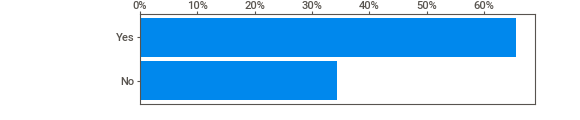
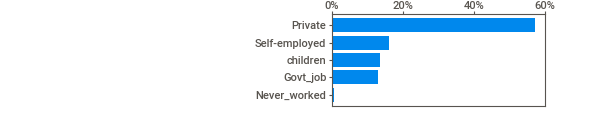
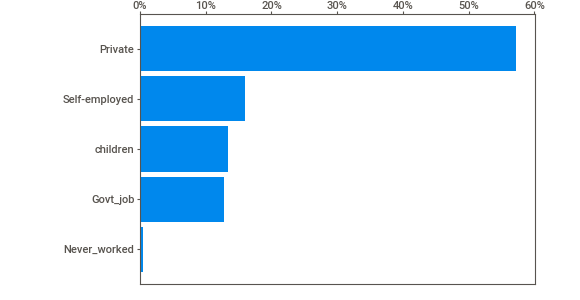
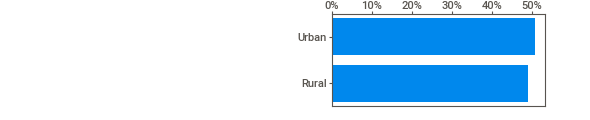
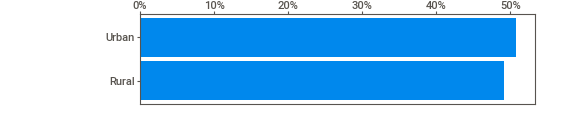
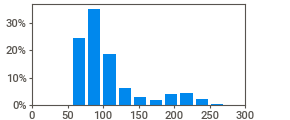
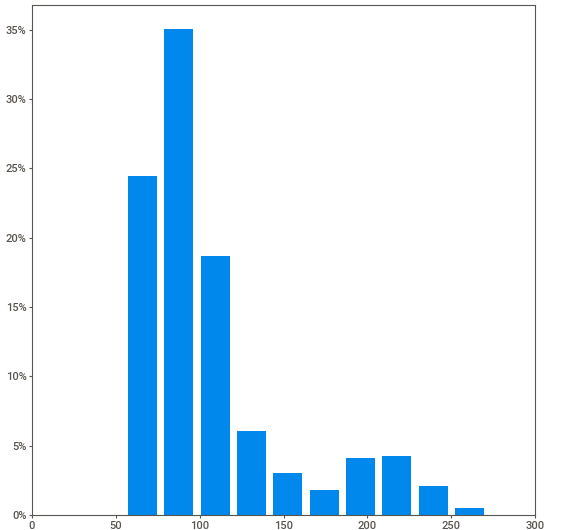
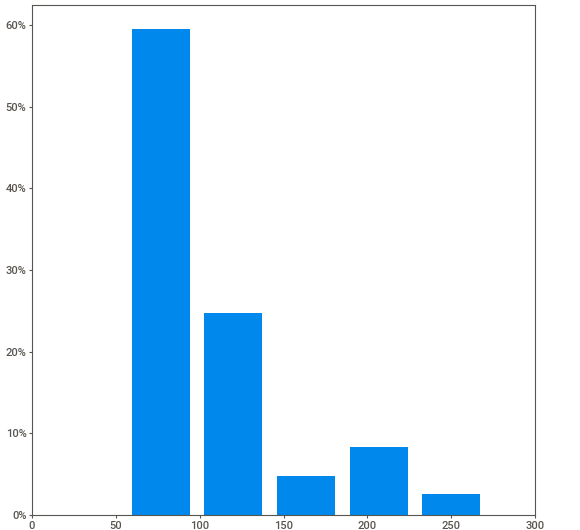
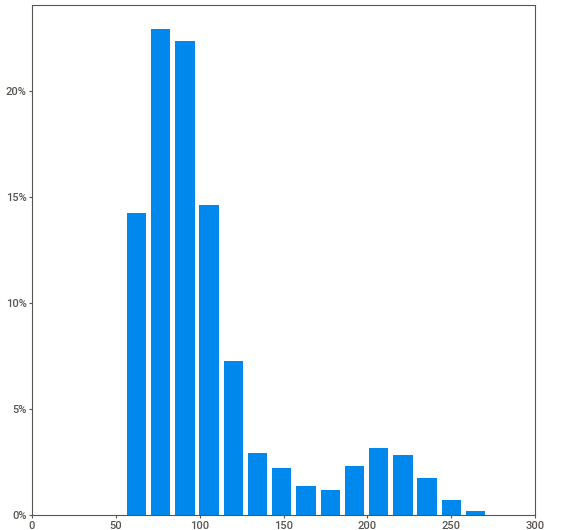
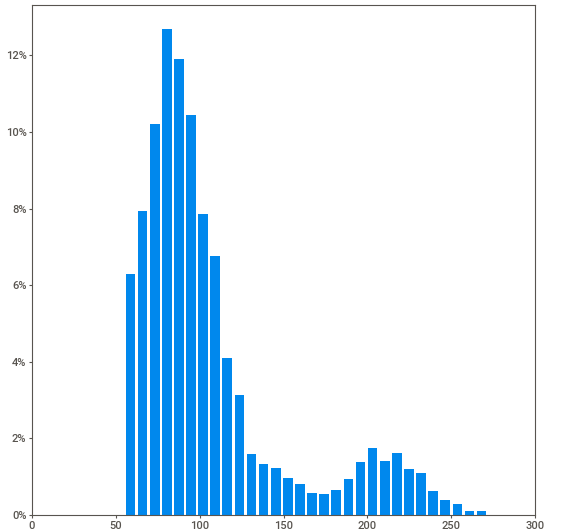
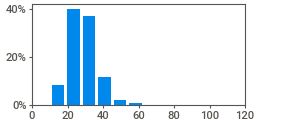
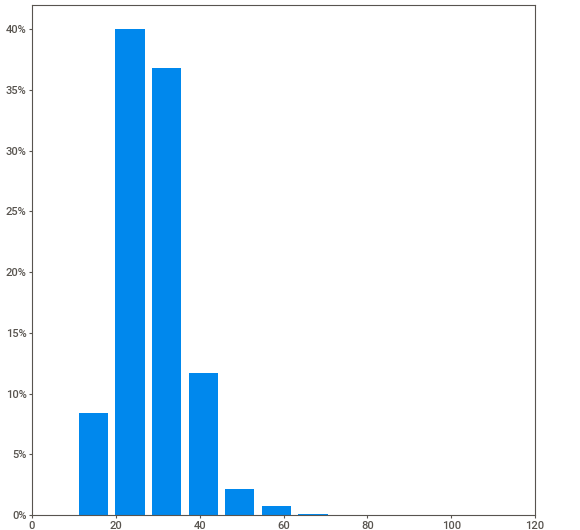
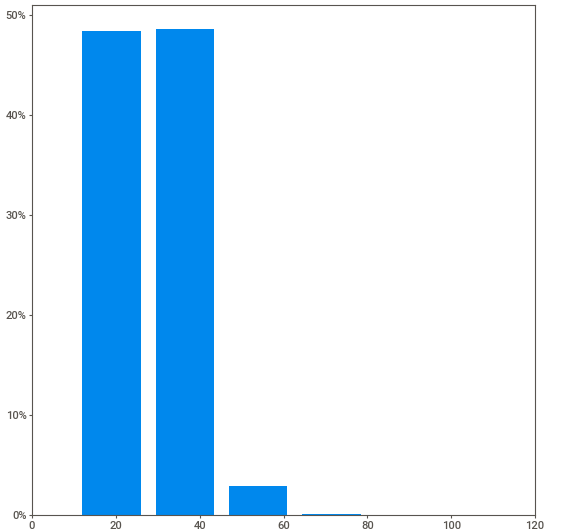
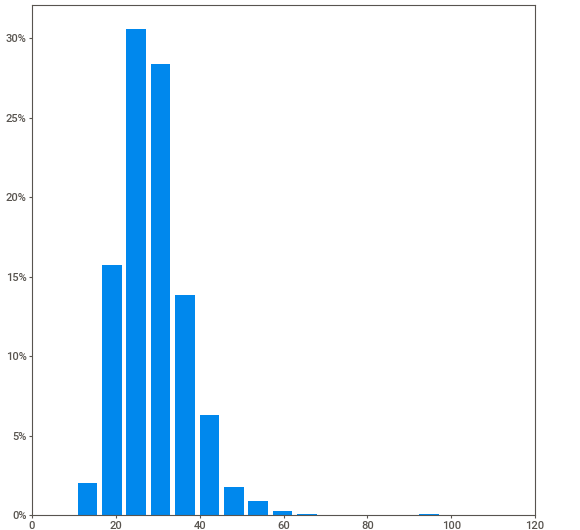
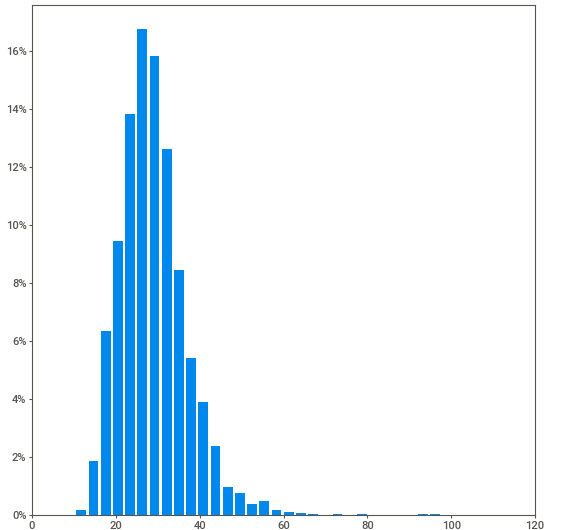
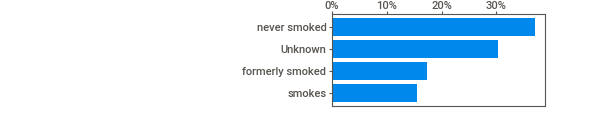
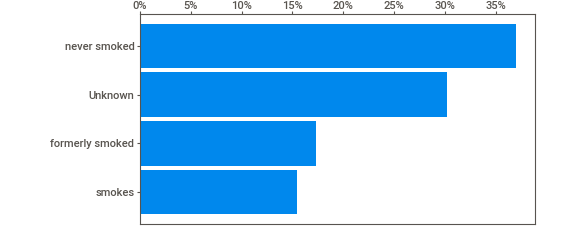
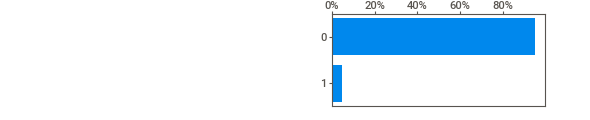
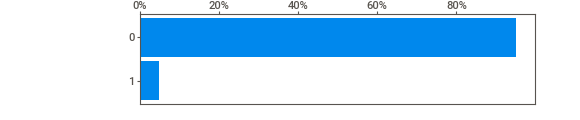
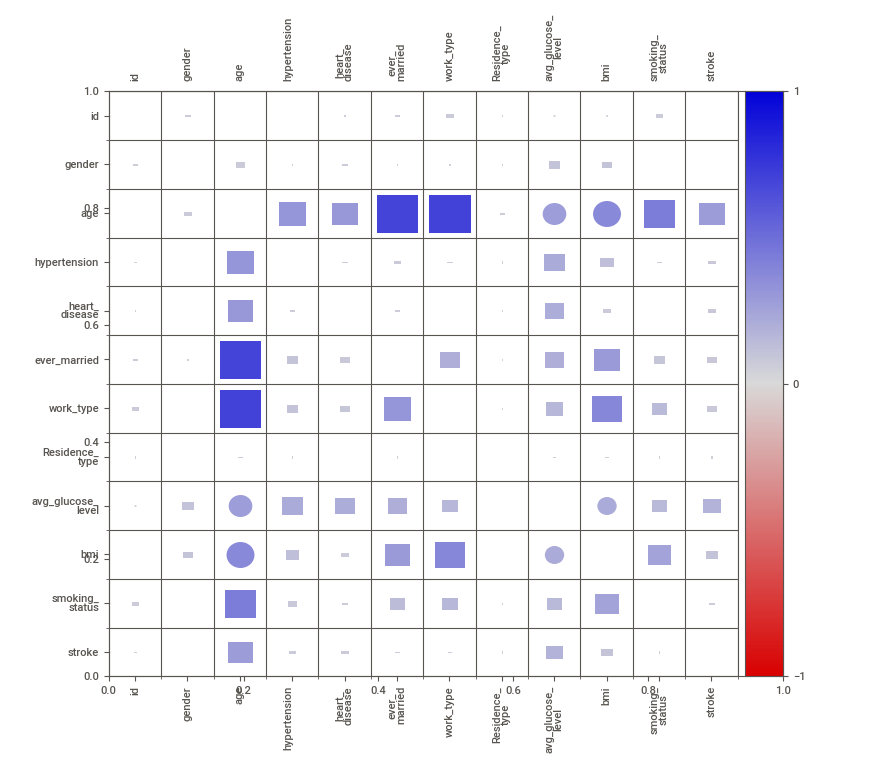
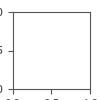

In [5]:
eda_report_sv.show_notebook()

In [7]:
eda_report_pp.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 12/12 [00:00<00:00, 124.74it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

✍️ **Interpretación:**
(Escribir aquí hallazgos relevantes y comparación entre librerías).

Consideramos Ydata-profiling una libreria superior a Sweetviz, pues no solo nos da una descripción detallada de cada columna sino que tambien nos brinda graficos de dispersion de dos variables a nuestra elección, matriz de correlación y una muestra de los datos. Sin embargo, creemos que el poder procesar estas demás características lo haría lento frente a Sweetviz si es que tratasemos con datasets de muchas mas variables y/o registros.


##  Pregunta 2 – Análisis por cortes
- Definir **dos variables de corte distintas** (ejemplo: género, edad > 50, hipertensión, etc.).  
- Interpretar resultados y justificar la elección de las variables.  


In [ ]:
# Código aquí

✍️ **Interpretación:**
(Explicar si los cortes generan patrones relevantes respecto al target `stroke`).


##  Pregunta 3 – Relación entre pares de variables
- Escoger tres pares de variables: categórica×categórica, categórica×numérica y numérica×numérica.  
- Justificar la elección de variables y analizar relaciones encontradas.  


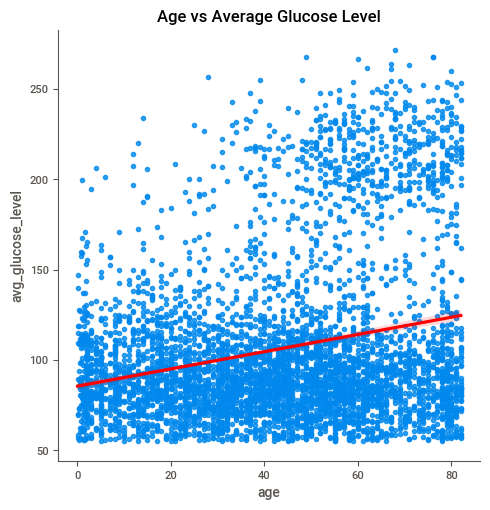

In [24]:
# Código aquí
sns.lmplot(x='age', y='avg_glucose_level', data=data, line_kws={'color': 'red'})
plt.title('Age vs Average Glucose Level')
plt.show()

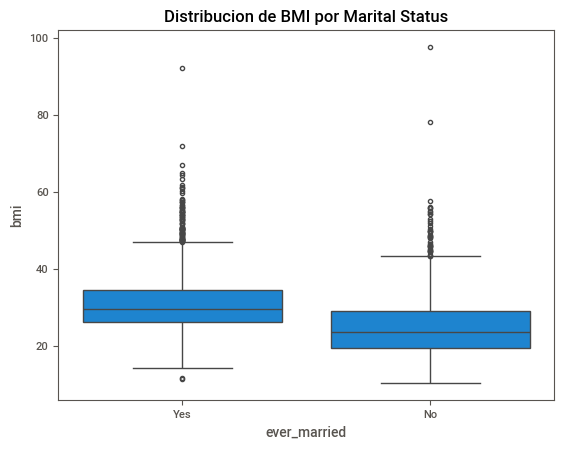

In [25]:
sns.boxplot(x='ever_married', y='bmi', data=data)
plt.title('Distribucion de BMI por Marital Status')
plt.show()

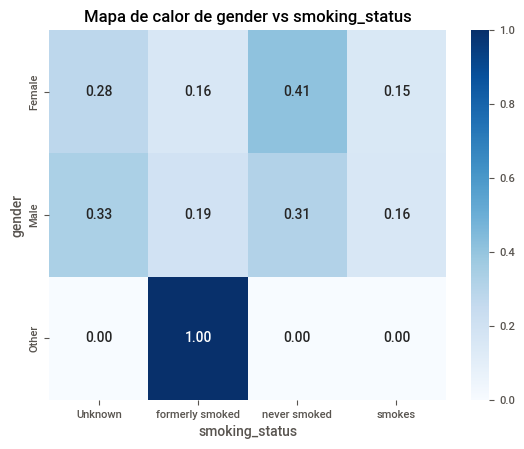

In [26]:
tabla = pd.crosstab(data['gender'], data['smoking_status'], normalize='index')
sns.heatmap(tabla, annot=True, cmap='Blues', fmt=".2f")
plt.title('Mapa de calor de gender vs smoking_status')
plt.show()

✍️ **Interpretación:**
(Analizar relevancia de las relaciones con respecto al target `stroke`).

###

### Interpretacion de variables Numerica x Numerica (age VS avg_glucose_level)
Se observa que la pendiente ascendente de la regresión indica que a medida que aumenta la edad, también aumenta el nivel promedio de glucosa en sangre. Esta relación la consideramos relevante, pues podria ser el primer indicio que indique que el riesgo de 'stroke' aumenta en pacientes mayores con niveles más altos de glucosa.

### Interpretacion de variabes Categorica x Numerica (ever_married VS bmi)
El grupo de personas que han estado casadas(Yes) tiene una mediana de BMI más alta comparado con el grupo que no lo ha estado ('no'); sugiriendono que en promedio, las personas casadas tienden a tener un índice de masa corporal más elevado. Esta relación podria ser relevante, pues si confirmasemos que un BMI elevado es un factor de riesgo para el 'stroke', esto también podría indicar que el riesgo es mayor en pacientes casados, permitiendo así enfocar nuestra  atención en un grupo más específico.

### Interpretacion de variables Categorica x Categorica (gender VS smoking_status)

Las mujeres presentan una mayor proporción de personas que nunca han fumado, mientras que los hombres tienen porcentajes más altos. Esta diferencias podrían ser relevantes, ya que de llegar a confirmar si los fumadores o exfumadores tienden a presentar un 'stroke' positivo, estas podrían ayudar a identificar otro grupo de mayor riesgo.


##  Pregunta 4 – Preprocesamiento con Pipelines
- Implementar un **pipeline de sklearn/imblearn** que incluya:  
  - Conversión de variables categóricas.  
  - Escalado de numéricas.  
  - Estrategia de **balanceo de clases** (ej. SMOTE, undersampling o class_weight).  
- Comparar desempeño con un clasificador auxiliar antes y después del pipeline.  


In [27]:
# Código aquí

✍️ **Interpretación:**
(Justificar elecciones de preprocesamiento y analizar impacto en desempeño).


## Pregunta 5 – Feature Engineering
- Crear al menos **dos nuevas variables derivadas**.  
- Explicar la lógica detrás de estas transformaciones.  
- Evaluar con un clasificador auxiliar si mejoran el desempeño predictivo.  


In [28]:
# Código aquí

✍️ **Interpretación:**
(Explicar lógica de las variables creadas y comparar desempeño con/sin ellas).


# Rúbrica de Evaluación – Práctica Calificada

| Pregunta | Criterio | Descripción | Puntaje Máximo |
|----------|-----------|-------------|----------------|
| **1. EDA con librerías automáticas** | Codificación | Implementa correctamente el EDA con SweetViz y otra librería. | **1.5** |
| | Interpretación | Explica hallazgos, compara herramientas, identifica ventajas/desventajas. | **2.5** |
| **2. Análisis por cortes** | Codificación | Realiza correctamente los cortes en dos variables y presenta resultados claros. | **1.5** |
| | Interpretación | Justifica la elección de variables, interpreta patrones y su relación con el target. | **2.5** |
| **3. Relación entre pares de variables** | Codificación | Escoge tres pares (cat×cat, cat×num, num×num) y aplica correctamente métodos de análisis. | **1.5** |
| | Interpretación | Justifica selección, analiza relaciones y discute relevancia en `stroke`. | **2.5** |
| **4. Preprocesamiento con Pipelines** | Codificación | Implementa pipeline con categóricas, escalado y balanceo. Evalúa antes y después. | **1.5** |
| | Interpretación | Justifica decisiones, analiza impacto en desempeño, discute limitaciones. | **2.5** |
| **5. Feature Engineering** | Codificación | Crea al menos dos nuevas variables, integra y evalúa con clasificador auxiliar. | **1.5** |
| | Interpretación | Explica lógica de transformaciones, analiza relevancia y compara desempeño. | **2.5** |

**Total por pregunta:** 4 puntos  
**Total práctica:** 20 puntos  
